# 电商客户分群与生命周期分析

## 业务问题

客户不能只按消费金额从高到低排列。企业还需要知道：谁是持续购买的高价值客户，谁正在沉睡，谁是刚进入生命周期的新客，以及哪些客户属于低互动长尾。

本项目使用真实交易记录，在固定观察截止日构造客户行为特征，比较 **K-Means、层次聚类、Gaussian Mixture 和 HDBSCAN**。聚类只使用截止日前的数据；截止日后的 90 天购买行为只用于检验分群是否具有业务区分度。

## 项目亮点

- 从 106 万余条交易明细构造客户级特征层；
- 同时考虑 RFM、生命周期、购买节奏、商品丰富度、近期趋势和取消行为；
- 用轮廓系数、Davies–Bouldin、最小群体占比和扰动稳定性选择聚类数量；
- 比较划分式、层次式、概率式和密度式聚类；
- 用未来 90 天真实复购表现进行样本外业务验证；
- 输出运营可用的分群画像，但不把聚类解释成自然存在的“真实人格类型”。


## 1. 数据来源与分析边界

数据来自 UCI Machine Learning Repository 的 **Online Retail II**，记录一家英国非门店零售商在 2009-12-01 至 2011-12-09 的交易。

- 官方页面：https://archive.ics.uci.edu/dataset/502/online+retail+ii
- DOI：https://doi.org/10.24432/C5CG6D
- 许可：CC BY 4.0

公开数据只有约六千名可识别客户，因此本项目证明的是客户分群方法和验证流程，不能替代简历中工作经历所述的 150,000+ 样本规模。


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

search_roots = [Path.cwd(), *Path.cwd().parents]
PORTFOLIO_ROOT = next(
    root for root in search_roots
    if (root / "data/raw/online_retail_ii/online_retail_II.xlsx").exists()
)
DATA_PATH = PORTFOLIO_ROOT / "data/raw/online_retail_ii/online_retail_II.xlsx"
PROJECT_DIR = PORTFOLIO_ROOT / "projects/04_customer_analytics"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = pd.Timestamp("2011-09-01")
OBSERVATION_START = CUTOFF - pd.Timedelta(days=365)
VALIDATION_END = CUTOFF + pd.Timedelta(days=90)

print(f"数据文件：{DATA_PATH.relative_to(PORTFOLIO_ROOT)}")
print(f"观察窗口：{OBSERVATION_START.date()} 至 {CUTOFF.date()}（不含截止日）")
print(f"未来验证窗口：{CUTOFF.date()} 至 {VALIDATION_END.date()}（不含结束日）")
display(Markdown(
    "**结果解释：**所有聚类特征都来自观察截止日前；未来90天只用于结果验证。"
    "这相当于企业在 2011-09-01 运行一次月度客户分群，并在三个月后检查各群体的实际表现。"
))


数据文件：data\raw\online_retail_ii\online_retail_II.xlsx
观察窗口：2010-09-01 至 2011-09-01（不含截止日）
未来验证窗口：2011-09-01 至 2011-11-30（不含结束日）


**结果解释：**所有聚类特征都来自观察截止日前；未来90天只用于结果验证。这相当于企业在 2011-09-01 运行一次月度客户分群，并在三个月后检查各群体的实际表现。

## 2. 读取、清洗并区分成功购买与取消交易

In [2]:
sheets = pd.ExcelFile(DATA_PATH).sheet_names
raw = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in sheets], ignore_index=True)
raw.columns = [
    "invoice", "stock_code", "description", "quantity",
    "invoice_date", "unit_price", "customer_id", "country"
]
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])
raw["invoice"] = raw["invoice"].astype(str).str.strip()
raw["stock_code"] = raw["stock_code"].astype(str).str.strip()
raw["is_cancelled"] = raw.invoice.str.upper().str.startswith("C") | (raw.quantity < 0)

identified = raw.loc[raw.customer_id.notna()].copy()
identified["customer_id"] = identified.customer_id.astype(int).astype(str)
successful = identified.loc[
    ~identified.is_cancelled & (identified.quantity > 0) & (identified.unit_price > 0)
].copy()
successful["revenue"] = successful.quantity * successful.unit_price
cancelled = identified.loc[identified.is_cancelled].copy()
cancelled["cancelled_value_abs"] = (cancelled.quantity * cancelled.unit_price).abs()

audit = pd.DataFrame({
    "指标": ["原始商品行", "可识别客户", "客户编号缺失率", "成功购买商品行", "取消/负数量商品行"],
    "结果": [
        f"{len(raw):,}", f"{identified.customer_id.nunique():,}",
        f"{raw.customer_id.isna().mean():.2%}", f"{len(successful):,}", f"{len(cancelled):,}"
    ]
})
display(audit)
display(Markdown(
    f"**结果解释：**原始数据有 **{len(raw):,}** 条商品行、**{identified.customer_id.nunique():,}** 个可识别客户。"
    f"建模使用 **{len(successful):,}** 条成功购买明细；取消交易单独保留为售后行为特征。"
    "缺失客户编号的交易无法连接成客户历史，因此不进入分群，但缺失比例被保留在审计结果中。"
))


,指标,结果
0,原始商品行,"1,067,371"
1,可识别客户,"5,942"
2,客户编号缺失率,22.77%
3,成功购买商品行,"805,549"
4,取消/负数量商品行,"18,744"


**结果解释：**原始数据有 **1,067,371** 条商品行、**5,942** 个可识别客户。建模使用 **805,549** 条成功购买明细；取消交易单独保留为售后行为特征。缺失客户编号的交易无法连接成客户历史，因此不进入分群，但缺失比例被保留在审计结果中。

## 3. 构造客户特征层

观察窗口采用过去 365 天，避免早期历史无限累积。客户必须在观察窗口内至少有一次成功购买。特征分为：

- **价值与频次：**订单数、消费额、件数、客单价；
- **生命周期：**距最近购买天数、客户年龄、活跃月份；
- **兴趣广度：**不同商品数量、每单商品行数；
- **节奏与趋势：**订单间隔、近90天订单及消费占比；
- **售后行为：**取消发票率和取消金额占比。


In [3]:
history_all = successful.loc[successful.invoice_date < CUTOFF].copy()
obs = successful.loc[
    (successful.invoice_date >= OBSERVATION_START) & (successful.invoice_date < CUTOFF)
].copy()
obs_cancelled = cancelled.loc[
    (cancelled.invoice_date >= OBSERVATION_START) & (cancelled.invoice_date < CUTOFF)
].copy()

order_level = obs.groupby(["customer_id", "invoice"], as_index=False).agg(
    order_date=("invoice_date", "min"), order_value=("revenue", "sum"),
    order_units=("quantity", "sum"), order_lines=("stock_code", "size")
)
customers = order_level.groupby("customer_id").agg(
    orders_365d=("invoice", "nunique"), spend_365d=("order_value", "sum"),
    units_365d=("order_units", "sum"), avg_order_value=("order_value", "mean"),
    avg_lines_per_order=("order_lines", "mean"), last_purchase=("order_date", "max")
)
customers["recency_days"] = (CUTOFF - customers.last_purchase).dt.total_seconds() / 86400
first_purchase = history_all.groupby("customer_id").invoice_date.min()
customers["tenure_days"] = (CUTOFF - first_purchase.reindex(customers.index)).dt.total_seconds() / 86400
customers["active_months"] = obs.assign(month=obs.invoice_date.dt.to_period("M")).groupby("customer_id").month.nunique()
customers["distinct_skus"] = obs.groupby("customer_id").stock_code.nunique()

def order_gap_stats(group):
    dates = group.order_date.drop_duplicates().sort_values()
    gaps = dates.diff().dt.total_seconds().div(86400).dropna()
    return pd.Series({"mean_order_gap_days": gaps.mean(), "std_order_gap_days": gaps.std()})

customers = customers.join(order_level.groupby("customer_id", group_keys=False).apply(order_gap_stats))

recent_start = CUTOFF - pd.Timedelta(days=90)
recent = order_level.loc[order_level.order_date >= recent_start]
recent_agg = recent.groupby("customer_id").agg(
    recent_orders_90d=("invoice", "nunique"), recent_spend_90d=("order_value", "sum")
)
customers = customers.join(recent_agg, how="left").fillna({"recent_orders_90d": 0, "recent_spend_90d": 0})
customers["recent_order_share"] = customers.recent_orders_90d / customers.orders_365d.clip(lower=1)
customers["recent_spend_share"] = customers.recent_spend_90d / customers.spend_365d.clip(lower=0.01)

cancel_invoice = obs_cancelled.groupby("customer_id").invoice.nunique()
cancel_value = obs_cancelled.groupby("customer_id").cancelled_value_abs.sum()
customers["cancelled_invoice_rate"] = cancel_invoice.reindex(customers.index, fill_value=0) / (customers.orders_365d + cancel_invoice.reindex(customers.index, fill_value=0)).clip(lower=1)
customers["cancelled_value_ratio"] = cancel_value.reindex(customers.index, fill_value=0) / customers.spend_365d.clip(lower=0.01)
main_country = obs.groupby("customer_id").country.agg(lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown")
customers["is_uk"] = main_country.reindex(customers.index).eq("United Kingdom").astype(int)
customers = customers.drop(columns="last_purchase")

CLUSTER_FEATURES = [
    "recency_days", "tenure_days", "orders_365d", "spend_365d",
    "units_365d", "avg_order_value", "active_months", "distinct_skus",
    "avg_lines_per_order", "mean_order_gap_days", "std_order_gap_days",
    "recent_order_share", "recent_spend_share",
    "cancelled_invoice_rate", "cancelled_value_ratio"
]

summary = customers[CLUSTER_FEATURES].describe(percentiles=[.25, .5, .75, .99]).T
display(summary[["count", "mean", "50%", "75%", "99%", "max"]].style.format("{:,.2f}"))
display(Markdown(
    f"**结果解释：**观察窗口内共有 **{len(customers):,}** 名可分群客户，生成 **{len(CLUSTER_FEATURES)}** 个聚类特征。"
    "消费、订单和取消金额存在明显长尾，直接使用原值会让少数极端客户支配欧氏距离；"
    "下一步将在训练口径内进行99%分位截尾、缺失填补、偏态变换和标准化。"
))


,count,mean,50%,75%,99%,max
recency_days,"4,335.00",143.94,111.33,269.41,357.10,364.58
tenure_days,"4,335.00",404.37,429.41,574.47,638.44,638.68
orders_365d,"4,335.00",4.11,2.00,4.00,28.00,186.00
spend_365d,"4,335.00","1,981.95",665.78,"1,621.15","18,562.11","268,575.55"
units_365d,"4,335.00","1,165.95",370.00,935.50,"10,642.84","191,529.00"
avg_order_value,"4,335.00",413.40,300.65,445.67,"1,998.06","77,183.60"
active_months,"4,335.00",2.86,2.00,4.00,12.00,12.00
distinct_skus,"4,335.00",58.75,34.00,73.00,340.32,"1,647.00"
avg_lines_per_order,"4,335.00",22.86,17.50,29.00,107.83,219.00
mean_order_gap_days,"2,760.00",68.43,51.10,90.60,285.95,336.02


**结果解释：**观察窗口内共有 **4,335** 名可分群客户，生成 **15** 个聚类特征。消费、订单和取消金额存在明显长尾，直接使用原值会让少数极端客户支配欧氏距离；下一步将在训练口径内进行99%分位截尾、缺失填补、偏态变换和标准化。

## 4. 预处理：抑制极端值并统一距离尺度

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

feature_frame = customers[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan).copy()
caps = feature_frame.quantile(0.99)
floors = feature_frame.quantile(0.01)
feature_capped = feature_frame.clip(lower=floors, upper=caps, axis=1)

imputer = SimpleImputer(strategy="median")
imputed = pd.DataFrame(imputer.fit_transform(feature_capped), index=feature_capped.index, columns=CLUSTER_FEATURES)
LOG_FEATURES = [
    "recency_days", "tenure_days", "orders_365d", "spend_365d", "units_365d",
    "avg_order_value", "active_months", "distinct_skus", "avg_lines_per_order",
    "mean_order_gap_days", "std_order_gap_days", "cancelled_value_ratio"
]
transformed = imputed.copy()
transformed[LOG_FEATURES] = np.log1p(transformed[LOG_FEATURES].clip(lower=0))
scaler = StandardScaler()
X = scaler.fit_transform(transformed)

check = pd.DataFrame({
    "检查": ["客户数", "特征数", "预处理后缺失值", "标准化均值绝对值最大值", "标准化标准差范围"],
    "结果": [len(customers), len(CLUSTER_FEATURES), int(np.isnan(X).sum()),
             float(np.abs(X.mean(axis=0)).max()), f"{X.std(axis=0).min():.3f}–{X.std(axis=0).max():.3f}"]
})
display(check)
display(Markdown(
    "**结果解释：**预处理后没有缺失值，各特征均被调整到可比较尺度。"
    "1%–99%截尾不会删除客户，只限制极端值对距离的影响；对偏态特征使用 `log1p`，保留相对高低关系但压缩长尾。"
))


,检查,结果
0,客户数,4335
1,特征数,15
2,预处理后缺失值,0
3,标准化均值绝对值最大值,0.000
4,标准化标准差范围,1.000–1.000


**结果解释：**预处理后没有缺失值，各特征均被调整到可比较尺度。1%–99%截尾不会删除客户，只限制极端值对距离的影响；对偏态特征使用 `log1p`，保留相对高低关系但压缩长尾。

## 5. K-Means：选择可运营的分群数量

候选范围为 2–8 群。评价指标：

- **Silhouette：**越高越好；
- **Davies–Bouldin：**越低越好；
- **扰动稳定性：**给标准化特征加入少量噪声后，标签与原标签的 ARI，越接近1越稳定；
- **最小群体占比：**避免产生无法运营的微小群体。

为了兼顾统计质量和运营可解释性，最终从 4–6 群且最小群体不少于3%的方案中，用三项指标综合排名选择。


  File "C:\Users\J\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,silhouette,davies_bouldin,calinski_harabasz,stability_ari,min_cluster_share,rank_score
0,2,0.228,1.659,"1,253",0.987,38.9%,11.0
1,3,0.270,1.376,"1,221",0.990,11.7%,3.0
2,4,0.199,1.617,"1,070",0.970,10.5%,18.0
3,5,0.224,1.501,991,0.974,9.5%,13.0
4,6,0.196,1.466,964,0.975,2.7%,15.0
5,7,0.203,1.456,900,0.977,2.4%,11.0
6,8,0.204,1.395,854,0.916,2.3%,13.0


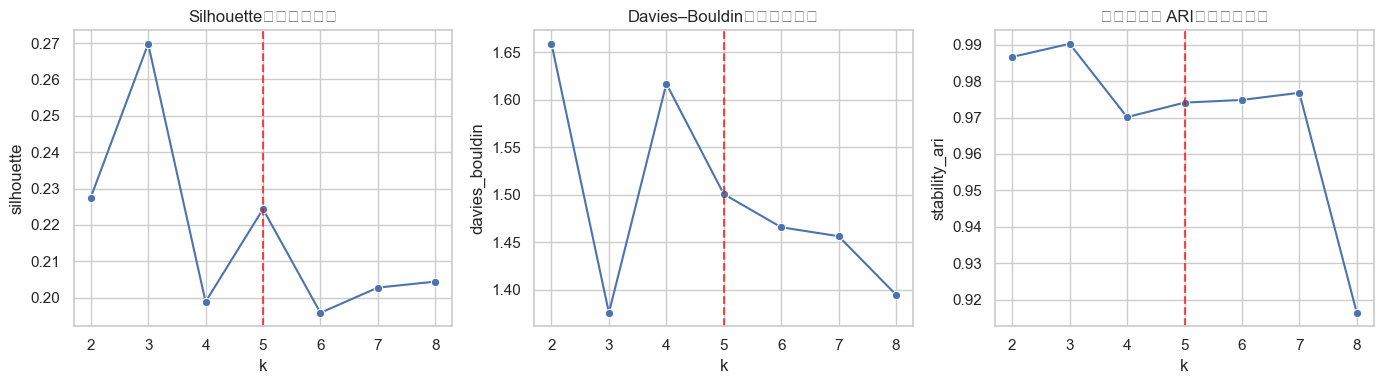

**结果解释：**综合统计质量、稳定性和可运营粒度，选择 **5 群**。该方案 Silhouette 为 **0.224**、稳定性 ARI 为 **0.974**，最小群体占比为 **9.5%**。选择不是只追求单一指标最高值：过少群体可能掩盖生命周期差异，过多群体则会降低稳定性和运营可执行性。当前 Silhouette 仅表示中等偏弱的自然分离，因此五群应被理解为运营上的实用简化，而不是客户天然存在五种类型。

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)

rng = np.random.default_rng(42)
k_rows = []
for k in range(2, 9):
    base = KMeans(n_clusters=k, n_init=30, random_state=42).fit(X)
    labels = base.labels_
    stability = []
    for repeat in range(6):
        noisy_X = X + rng.normal(0, 0.03, size=X.shape)
        noisy_labels = KMeans(n_clusters=k, n_init=15, random_state=100 + repeat).fit_predict(noisy_X)
        stability.append(adjusted_rand_score(labels, noisy_labels))
    shares = pd.Series(labels).value_counts(normalize=True)
    k_rows.append({
        "k": k, "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "stability_ari": np.mean(stability), "min_cluster_share": shares.min()
    })

k_selection = pd.DataFrame(k_rows)
k_selection["rank_score"] = (
    k_selection.silhouette.rank(ascending=False) +
    k_selection.davies_bouldin.rank(ascending=True) +
    k_selection.stability_ari.rank(ascending=False)
)
viable = k_selection.query("4 <= k <= 6 and min_cluster_share >= 0.03")
if viable.empty:
    viable = k_selection.query("min_cluster_share >= 0.03")
SELECTED_K = int(viable.sort_values(["rank_score", "silhouette"]).iloc[0].k)

display(k_selection.style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:,.0f}", "stability_ari": "{:.3f}",
    "min_cluster_share": "{:.1%}", "rank_score": "{:.1f}"
}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.lineplot(data=k_selection, x="k", y="silhouette", marker="o", ax=axes[0])
sns.lineplot(data=k_selection, x="k", y="davies_bouldin", marker="o", ax=axes[1])
sns.lineplot(data=k_selection, x="k", y="stability_ari", marker="o", ax=axes[2])
axes[0].set_title("Silhouette（越高越好）")
axes[1].set_title("Davies–Bouldin（越低越好）")
axes[2].set_title("扰动稳定性 ARI（越高越好）")
for ax in axes: ax.axvline(SELECTED_K, ls="--", color="red", alpha=.7)
plt.tight_layout(); plt.show()

k_selection.to_csv(OUTPUT_DIR / "kmeans_k_selection.csv", index=False)
selected_row = k_selection.set_index("k").loc[SELECTED_K]
display(Markdown(
    f"**结果解释：**综合统计质量、稳定性和可运营粒度，选择 **{SELECTED_K} 群**。"
    f"该方案 Silhouette 为 **{selected_row.silhouette:.3f}**、稳定性 ARI 为 **{selected_row.stability_ari:.3f}**，"
    f"最小群体占比为 **{selected_row.min_cluster_share:.1%}**。"
    "选择不是只追求单一指标最高值：过少群体可能掩盖生命周期差异，过多群体则会降低稳定性和运营可执行性。"
    "当前 Silhouette 仅表示中等偏弱的自然分离，因此五群应被理解为运营上的实用简化，而不是客户天然存在五种类型。"
))


## 6. 比较 K-Means、层次聚类、Gaussian Mixture 与 HDBSCAN

,algorithm,clusters,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,noise_share
0,K-Means,5,0.225,1.500,991,9.5%,0.0%
1,Hierarchical (Ward),5,0.212,1.390,838,1.6%,0.0%
2,Gaussian Mixture,5,0.154,1.900,808,9.1%,0.0%
3,HDBSCAN,4,0.259,1.199,750,8.9%,68.3%


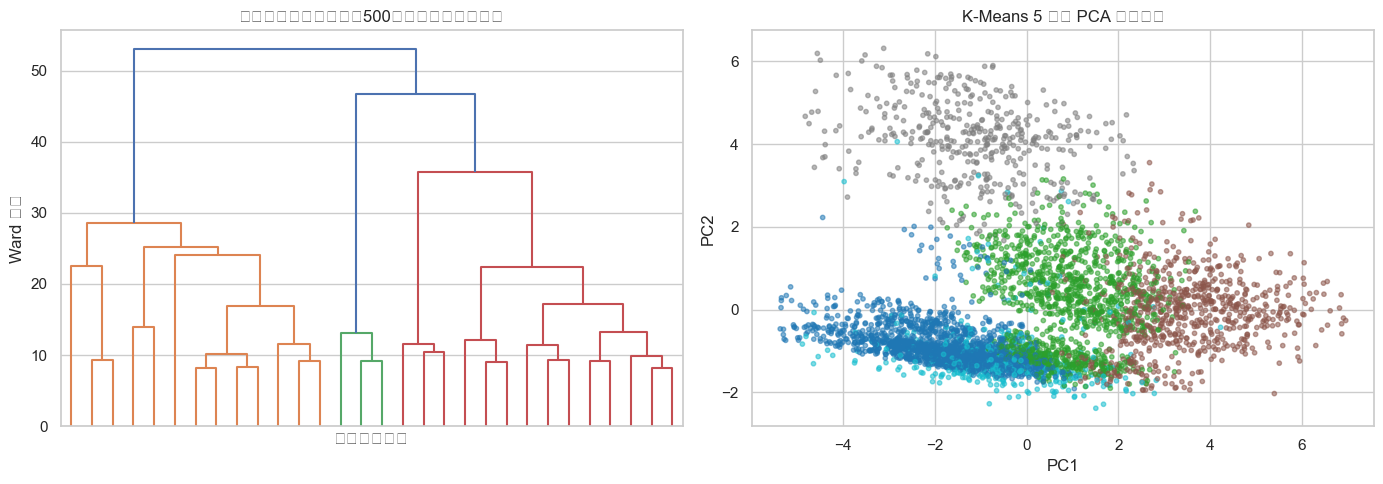

**结果解释：**四种算法使用完全相同的预处理特征。K-Means 与 Ward 层次聚类的标签一致性 ARI 为 **0.532**；HDBSCAN 自动识别 **4** 个非噪声群体，并将 **68.3%** 的客户标记为噪声。Ward 层次聚类的最小群体只有 **1.6%**，而 HDBSCAN 的噪声比例过高，二者都不适合作为当前运营主方案。PCA 图只是高维结构的二维投影，点云重叠不等于原始15维空间无法区分。最终采用 K-Means 作为运营分群，是因为它可复现、可给新客户分配最近中心，并能直接对照简历中的方法；层次聚类用于结构验证。

In [6]:
from sklearn.cluster import AgglomerativeClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA

def algorithm_metrics(name, labels, noise_label=None):
    labels = np.asarray(labels)
    valid = np.ones(len(labels), dtype=bool) if noise_label is None else labels != noise_label
    valid_labels = labels[valid]
    n_clusters = len(np.unique(valid_labels))
    if n_clusters < 2:
        sil = db = ch = np.nan
    else:
        sil = silhouette_score(X[valid], valid_labels)
        db = davies_bouldin_score(X[valid], valid_labels)
        ch = calinski_harabasz_score(X[valid], valid_labels)
    shares = pd.Series(valid_labels).value_counts(normalize=True)
    return {
        "algorithm": name, "clusters": n_clusters, "silhouette": sil,
        "davies_bouldin": db, "calinski_harabasz": ch,
        "min_cluster_share": shares.min() if len(shares) else np.nan,
        "noise_share": 1 - valid.mean()
    }

kmeans = KMeans(n_clusters=SELECTED_K, n_init=50, random_state=42).fit(X)
agglomerative = AgglomerativeClustering(n_clusters=SELECTED_K, linkage="ward").fit(X)
gmm = GaussianMixture(n_components=SELECTED_K, covariance_type="full", n_init=5, random_state=42).fit(X)
hdbscan = HDBSCAN(min_cluster_size=max(40, int(len(X) * .02)), min_samples=15).fit(X)

algorithm_labels = {
    "K-Means": kmeans.labels_,
    "Hierarchical (Ward)": agglomerative.labels_,
    "Gaussian Mixture": gmm.predict(X),
    "HDBSCAN": hdbscan.labels_
}
algorithm_comparison = pd.DataFrame([
    algorithm_metrics(name, labels, -1 if name == "HDBSCAN" else None)
    for name, labels in algorithm_labels.items()
])
display(algorithm_comparison.style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:,.0f}", "min_cluster_share": "{:.1%}", "noise_share": "{:.1%}"
}))

sample_idx = rng.choice(len(X), size=min(500, len(X)), replace=False)
Z = linkage(X[sample_idx], method="ward")
pca = PCA(n_components=2, random_state=42).fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, no_labels=True, ax=axes[0])
axes[0].set(title="层次聚类树状图（随机500名客户，截断显示）", xlabel="合并后的节点", ylabel="Ward 距离")
scatter = axes[1].scatter(pca[:, 0], pca[:, 1], c=kmeans.labels_, s=10, alpha=.55, cmap="tab10")
axes[1].set(title=f"K-Means {SELECTED_K} 群的 PCA 二维投影", xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()

algorithm_comparison.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)
kmeans_hier_ari = adjusted_rand_score(kmeans.labels_, agglomerative.labels_)
ward_min_share = algorithm_comparison.set_index('algorithm').loc['Hierarchical (Ward)', 'min_cluster_share']
display(Markdown(
    f"**结果解释：**四种算法使用完全相同的预处理特征。K-Means 与 Ward 层次聚类的标签一致性 ARI 为 **{kmeans_hier_ari:.3f}**；"
    f"HDBSCAN 自动识别 **{algorithm_comparison.set_index('algorithm').loc['HDBSCAN', 'clusters']:.0f}** 个非噪声群体，"
    f"并将 **{algorithm_comparison.set_index('algorithm').loc['HDBSCAN', 'noise_share']:.1%}** 的客户标记为噪声。"
    f"Ward 层次聚类的最小群体只有 **{ward_min_share:.1%}**，而 HDBSCAN 的噪声比例过高，二者都不适合作为当前运营主方案。"
    "PCA 图只是高维结构的二维投影，点云重叠不等于原始15维空间无法区分。"
    "最终采用 K-Means 作为运营分群，是因为它可复现、可给新客户分配最近中心，并能直接对照简历中的方法；层次聚类用于结构验证。"
))


## 7. 客户群画像与业务命名

,cluster,segment,customers,customer_share,recency_days,tenure_days,orders_365d,spend_365d,avg_order_value,active_months,distinct_skus,mean_order_gap_days,recent_order_share,recent_spend_share,cancelled_invoice_rate,is_uk
2,2,高价值忠诚客户,743,17.1%,26,584,9,"£3,828",£388,7,113,31.1,21.4%,19.0%,15.2%,100.0%
1,1,稳定常购客户,"1,160",26.8%,64,505,3,"£1,107",£325,3,57,82.2,25.0%,21.2%,0.0%,100.0%
4,4,高取消/低活跃客户,411,9.5%,231,372,2,£584,£322,1,23,45.5,0.0%,0.0%,50.0%,100.0%
3,3,新晋/高潜客户,428,9.9%,34,64,1,£323,£252,1,20,27.2,100.0%,100.0%,0.0%,100.0%
0,0,沉睡风险客户,"1,593",36.7%,276,338,1,£312,£229,1,18,36.4,0.0%,0.0%,0.0%,100.0%


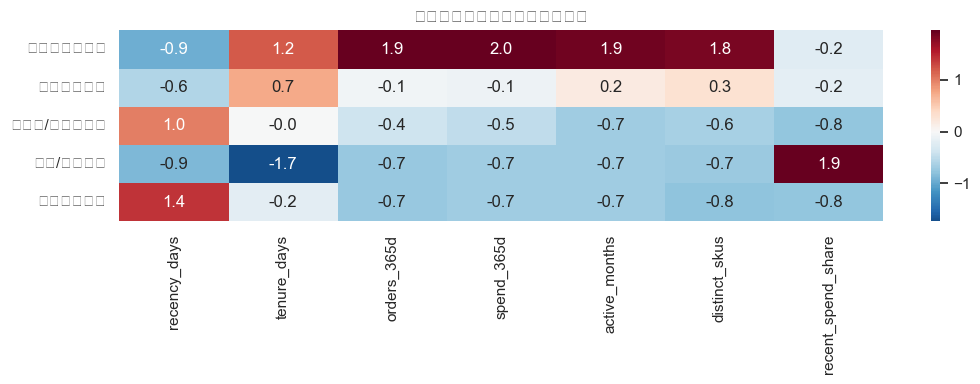

**结果解释：**最大群体是 **沉睡风险客户**，占客户的 **36.7%**；历史消费中位数最高的是 **高价值忠诚客户**，近365天消费中位数为 **£3,828**。热力图展示的是各群体相对于其他群体的高低，不是绝对金额。运营名称由可审计的相对规则生成；真正上线前仍应由业务团队检查名称是否符合品牌语言和可执行策略。

In [7]:
customers["cluster"] = kmeans.labels_
profile_cols = [
    "recency_days", "tenure_days", "orders_365d", "spend_365d", "avg_order_value",
    "active_months", "distinct_skus", "mean_order_gap_days",
    "recent_order_share", "recent_spend_share", "cancelled_invoice_rate", "is_uk"
]
profiles = customers.groupby("cluster").agg(
    customers=("orders_365d", "size"),
    **{col: (col, "median") for col in profile_cols}
).reset_index()
profiles["customer_share"] = profiles.customers / len(customers)

# 依据跨群体相对画像进行唯一命名；命名只用于运营沟通，不宣称是自然存在的人格类型。
zcols = ["recency_days", "tenure_days", "orders_365d", "spend_365d", "active_months", "recent_spend_share"]
z = profiles.set_index("cluster")[zcols].apply(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
remaining = set(profiles.cluster)
name_map = {}

def assign_best(label, score):
    candidates = score.loc[list(remaining)]
    cluster = int(candidates.idxmax())
    name_map[cluster] = label
    remaining.remove(cluster)

assign_best("高价值忠诚客户", z.spend_365d + z.orders_365d + z.active_months - z.recency_days)
if remaining:
    assign_best("沉睡风险客户", z.recency_days - z.recent_spend_share + .3 * z.tenure_days)
if remaining:
    assign_best("新晋/高潜客户", -z.tenure_days - .5 * z.orders_365d - .3 * z.recency_days)
if remaining:
    cancel_rate = profiles.set_index("cluster").cancelled_invoice_rate
    cancel_z = (cancel_rate - cancel_rate.mean()) / (cancel_rate.std(ddof=0) + 1e-9)
    if cancel_rate.loc[list(remaining)].max() >= 0.15:
        assign_best("高取消/低活跃客户", cancel_z - .3 * z.spend_365d)
    else:
        assign_best("低活跃长尾客户", -z.spend_365d - z.orders_365d + .5 * z.recency_days)
fallback_names = ["稳定常购客户", "发展中客户", "其他行为客户"]
for cluster, label in zip(sorted(remaining, key=lambda c: z.loc[c, "spend_365d"], reverse=True), fallback_names):
    name_map[int(cluster)] = label

customers["segment"] = customers.cluster.map(name_map)
profiles["segment"] = profiles.cluster.map(name_map)
profiles = profiles.sort_values("spend_365d", ascending=False)
display(profiles[["cluster", "segment", "customers", "customer_share", *profile_cols]].style.format({
    "customers": "{:,.0f}", "customer_share": "{:.1%}", "recency_days": "{:,.0f}",
    "tenure_days": "{:,.0f}", "orders_365d": "{:,.0f}", "spend_365d": "£{:,.0f}",
    "avg_order_value": "£{:,.0f}", "active_months": "{:,.0f}", "distinct_skus": "{:,.0f}",
    "mean_order_gap_days": "{:,.1f}", "recent_order_share": "{:.1%}",
    "recent_spend_share": "{:.1%}", "cancelled_invoice_rate": "{:.1%}", "is_uk": "{:.1%}"
}))

heat_cols = ["recency_days", "tenure_days", "orders_365d", "spend_365d", "active_months", "distinct_skus", "recent_spend_share"]
heat = profiles.set_index("segment")[heat_cols]
heat_z = heat.apply(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
plt.figure(figsize=(11, max(4, SELECTED_K * .75)))
sns.heatmap(heat_z, cmap="RdBu_r", center=0, annot=True, fmt=".1f")
plt.title("客户群相对画像（列内标准分）")
plt.xlabel(""); plt.ylabel(""); plt.tight_layout(); plt.show()

profiles.to_csv(OUTPUT_DIR / "customer_segment_profiles.csv", index=False)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=CLUSTER_FEATURES)
centroids[LOG_FEATURES] = np.expm1(centroids[LOG_FEATURES]).clip(lower=0)
centroids.insert(0, "cluster", range(SELECTED_K))
centroids.insert(1, "segment", centroids.cluster.map(name_map))
centroids.to_csv(OUTPUT_DIR / "kmeans_centroids_transformed_back.csv", index=False)

largest = profiles.sort_values("customer_share", ascending=False).iloc[0]
highest = profiles.sort_values("spend_365d", ascending=False).iloc[0]
display(Markdown(
    f"**结果解释：**最大群体是 **{largest.segment}**，占客户的 **{largest.customer_share:.1%}**；"
    f"历史消费中位数最高的是 **{highest.segment}**，近365天消费中位数为 **£{highest.spend_365d:,.0f}**。"
    "热力图展示的是各群体相对于其他群体的高低，不是绝对金额。"
    "运营名称由可审计的相对规则生成；真正上线前仍应由业务团队检查名称是否符合品牌语言和可执行策略。"
))


## 8. 用未来90天购买表现验证分群

,segment,customers,repurchase_rate_90d,average_future_orders_90d,average_future_spend_90d,median_future_spend_90d,repurchase_ci_low,repurchase_ci_high
3,高价值忠诚客户,743,87.1%,3.52,"£2,339",£970,84.5%,89.3%
2,稳定常购客户,"1,160",60.4%,1.04,£414,£216,57.6%,63.2%
0,新晋/高潜客户,428,48.6%,1.05,£445,£0,43.9%,53.3%
4,高取消/低活跃客户,411,35.3%,0.59,£242,£0,30.8%,40.0%
1,沉睡风险客户,"1,593",27.9%,0.39,£127,£0,25.8%,30.2%


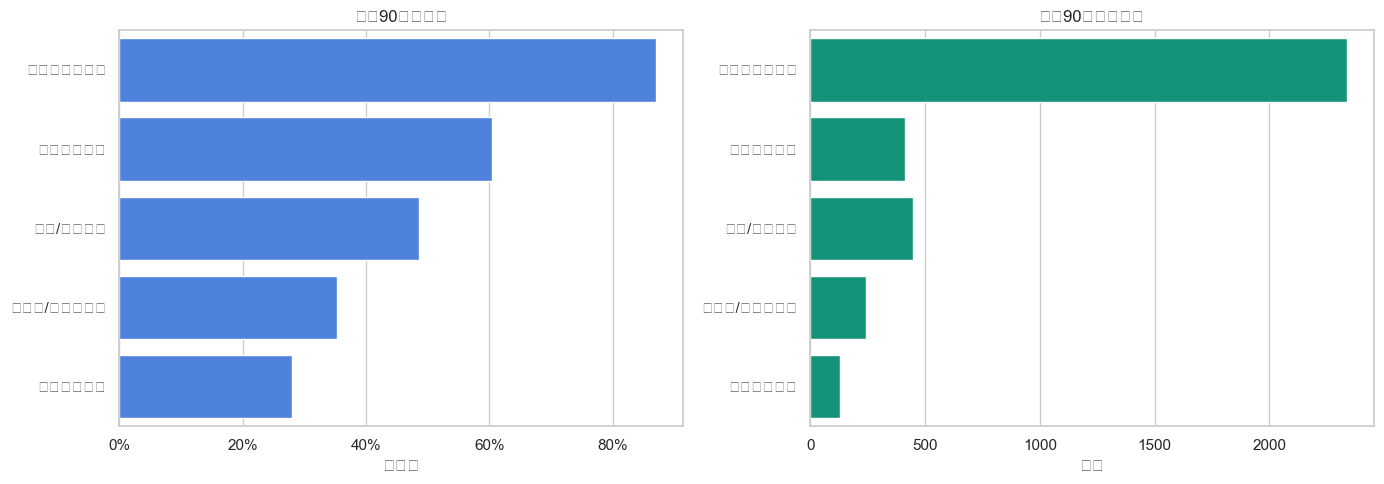

**结果解释：****高价值忠诚客户** 的未来90天复购率最高，为 **87.1%**；**沉睡风险客户** 最低，为 **27.9%**。未来行为没有参与聚类，因此群体之间的差异提供了样本外业务验证。但这仍是观察性结果：它说明分群与未来行为相关，不能证明针对某一群体发券一定会提高复购。

In [8]:
future = successful.loc[
    (successful.invoice_date >= CUTOFF) & (successful.invoice_date < VALIDATION_END)
].copy()
future_orders = future.groupby(["customer_id", "invoice"], as_index=False).agg(
    order_value=("revenue", "sum")
).groupby("customer_id").agg(
    future_orders_90d=("invoice", "nunique"), future_spend_90d=("order_value", "sum")
)
validation = customers.join(future_orders, how="left")
validation[["future_orders_90d", "future_spend_90d"]] = validation[["future_orders_90d", "future_spend_90d"]].fillna(0)
validation["repurchased_90d"] = (validation.future_orders_90d > 0).astype(int)

future_profile = validation.groupby("segment").agg(
    customers=("repurchased_90d", "size"),
    repurchase_rate_90d=("repurchased_90d", "mean"),
    average_future_orders_90d=("future_orders_90d", "mean"),
    average_future_spend_90d=("future_spend_90d", "mean"),
    median_future_spend_90d=("future_spend_90d", "median")
).reset_index().sort_values("repurchase_rate_90d", ascending=False)

# Wilson 95% 区间，展示各群复购率估计的不确定性。
z95 = 1.96
p = future_profile.repurchase_rate_90d
n = future_profile.customers
denom = 1 + z95**2 / n
center = (p + z95**2 / (2*n)) / denom
margin = z95 * np.sqrt((p*(1-p) + z95**2/(4*n))/n) / denom
future_profile["repurchase_ci_low"] = center - margin
future_profile["repurchase_ci_high"] = center + margin

display(future_profile.style.format({
    "customers": "{:,.0f}", "repurchase_rate_90d": "{:.1%}",
    "average_future_orders_90d": "{:.2f}", "average_future_spend_90d": "£{:,.0f}",
    "median_future_spend_90d": "£{:,.0f}", "repurchase_ci_low": "{:.1%}", "repurchase_ci_high": "{:.1%}"
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_order = future_profile.segment.tolist()
sns.barplot(data=future_profile, y="segment", x="repurchase_rate_90d", order=plot_order, ax=axes[0], color="#367BF5")
sns.barplot(data=future_profile, y="segment", x="average_future_spend_90d", order=plot_order, ax=axes[1], color="#00A884")
axes[0].set(title="未来90天复购率", xlabel="复购率", ylabel="")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].set(title="未来90天人均消费", xlabel="英镑", ylabel="")
plt.tight_layout(); plt.show()

future_profile.to_csv(OUTPUT_DIR / "segment_future_90d_validation.csv", index=False)
best = future_profile.iloc[0]
worst = future_profile.iloc[-1]
display(Markdown(
    f"**结果解释：****{best.segment}** 的未来90天复购率最高，为 **{best.repurchase_rate_90d:.1%}**；"
    f"**{worst.segment}** 最低，为 **{worst.repurchase_rate_90d:.1%}**。"
    "未来行为没有参与聚类，因此群体之间的差异提供了样本外业务验证。"
    "但这仍是观察性结果：它说明分群与未来行为相关，不能证明针对某一群体发券一定会提高复购。"
))


## 9. 运营建议与限制

### 分群如何进入运营

- **高价值忠诚客户：**权益维护、优先服务和新品测试，避免不必要的折扣侵蚀利润；
- **沉睡风险客户：**进入召回实验候选池，按历史价值和触达成本设置优先级；
- **新晋/高潜客户：**优化第二单引导和品类教育；
- **高取消/低活跃客户：**先排查商品、订单和取消原因，再决定服务补救或低成本触达，避免直接发放高额优惠；
- **低活跃长尾客户（若存在）：**采用低成本自动化触达，避免高额无差别补贴；
- **其他稳定或发展中群体：**通过交叉销售和生命周期内容提高活跃度。

### 必须保留的限制

1. 聚类结果取决于观察窗口、特征、缩放方式和聚类数量，不是唯一真相；
2. 群体名称是运营语言，不是模型直接输出的客户人格；
3. 数据没有毛利、营销成本或实验分配，不能计算分群策略的真实 ROI；
4. 未来复购差异是预测验证，不是营销动作的因果效果；
5. 公开项目只有数千名客户，不能宣称完成了 150,000+ 客户分群。

### 与简历的对应关系

本项目直接证明：

> Applied K-Means and hierarchical clustering for user segmentation.

同时展示了从交易清洗、特征工程、聚类数量选择、算法比较、稳定性检查到未来行为验证的可复现 Python 管道。简历中的 150,000+ 样本仍属于工作经历规模，网站应写成“demonstrates the same methodology on a public retail dataset”。
